In [1]:
import numpy as np
import barrier_heston_adi as bha
import importlib

importlib.reload(bha)

<module 'barrier_heston_adi' from 'c:\\Users\\Jialu\\Codes\\barrier-option\\barrier_heston_adi.py'>

<a id="step1"></a>
### 输入参数和网格构建
1. 期权参数
2. 计算域
3. 网格分辨率与拉伸

In [2]:
# input parameters for Knock-out call option
S0 = 100  # Initial stock price
K = 100  # Strike price
B = 80  # Barrier level
R = 0  # Rebate
T = 1  # Time to maturity
r = 0.02  # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04  # Long-term variance
sigma = 0.5  # Volatility of variance
rho = -0.7  # Correlation between the stock price and its variance

In [3]:
# Computational domain parameters
S_min = 0
S_max = 400
v_min = 0
v_max = 0.5

In [4]:
Ns = 200  # Number of stock price steps
Nv = 50  # Number of variance steps
Nt = 100  # Number of time steps

"""
c(Asset Clustering): Controls the density of points around the strike K.
A smaller c leads to more clustering of asset price steps around the K.
start with c = K/5, and adjust based on the observed convergence of the option price.
"""
c = 20  # Asset clustering factor.

"""
d(Variance Clustering): Controls the density of points near v = 0.
Volatility is highly convex near v = 0, and the PDE degenerate there.
A smaller d leads to more clustering of variance steps near v = 0.
start with d = v_max/10, and adjust based on the observed convergence of the option price.
"""
d = 0.05  # Variance clustering factor.

""" 
In 2D Alternative Direction Implicit (ADI) schemes, 
the theta parameter controls the implicitness of the time-stepping method.
Setting theta>=0.5 is strictly required to garantee the stability of the ADI scheme.
"""
theta_ADI = (
    1 / 3
)  # for the Craig-Sneyd scheme, theta_ADI = 1/3 is a common choice that provides a good balance between stability and accuracy.

双曲正弦拉伸

In [5]:
import numpy as np


def create_nonuniform_asset_grid(S_min, S_max, Ns, K, c, B=None):
    """
    Literature-standard sinh asset grid

    s_i = K + c * sinh(xi_i),

    where xi_i is uniformly spaced between the transformed lower/upper bounds.
    The optional barrier lets the PDE domain start at the knock-out boundary instead of
    at S_min, which aviods wasting points below the barrier.
    """
    if Ns < 2:
        raise ValueError("Ns must be at least 2 to create a grid.")
    if c <= 0:
        raise ValueError("Clustering parameter c must be positive.")

    lower = S_min if B is None else max(S_min, B)
    if lower >= S_max:
        raise ValueError("Lower bound must be less than S_max.")

    xi_min = np.arcsinh((lower - K) / c)
    xi_max = np.arcsinh((S_max - K) / c)
    xi = np.linspace(xi_min, xi_max, Ns)
    S_grid = K + c * np.sinh(xi)

    S_grid[0] = (
        lower  # Ensure the first node is exactly at the lower bound (S_min or B)
    )
    S_grid[-1] = S_max  # Ensure the last node is exactly at S_max

    return S_grid


def create_nonuniform_variance_grid(v_min, v_max, Nv, d):
    """
    Create a non-uniform grid for the variance with clustering near v=0.
    """
    # Create stretched coordinates in [0, 1]
    xi = np.linspace(0, 1, Nv)

    # Choose alpha so that d acts like a near-zero clustering scale
    alpha = np.arcsinh((v_max - v_min) / d)

    v_grid = v_min + d * np.sinh(alpha * xi)

    return v_grid


# Generate the non-uniform grids
S_grid = create_nonuniform_asset_grid(S_min, S_max, Ns, K, c, B)
v_grid = create_nonuniform_variance_grid(v_min, v_max, Nv, d)

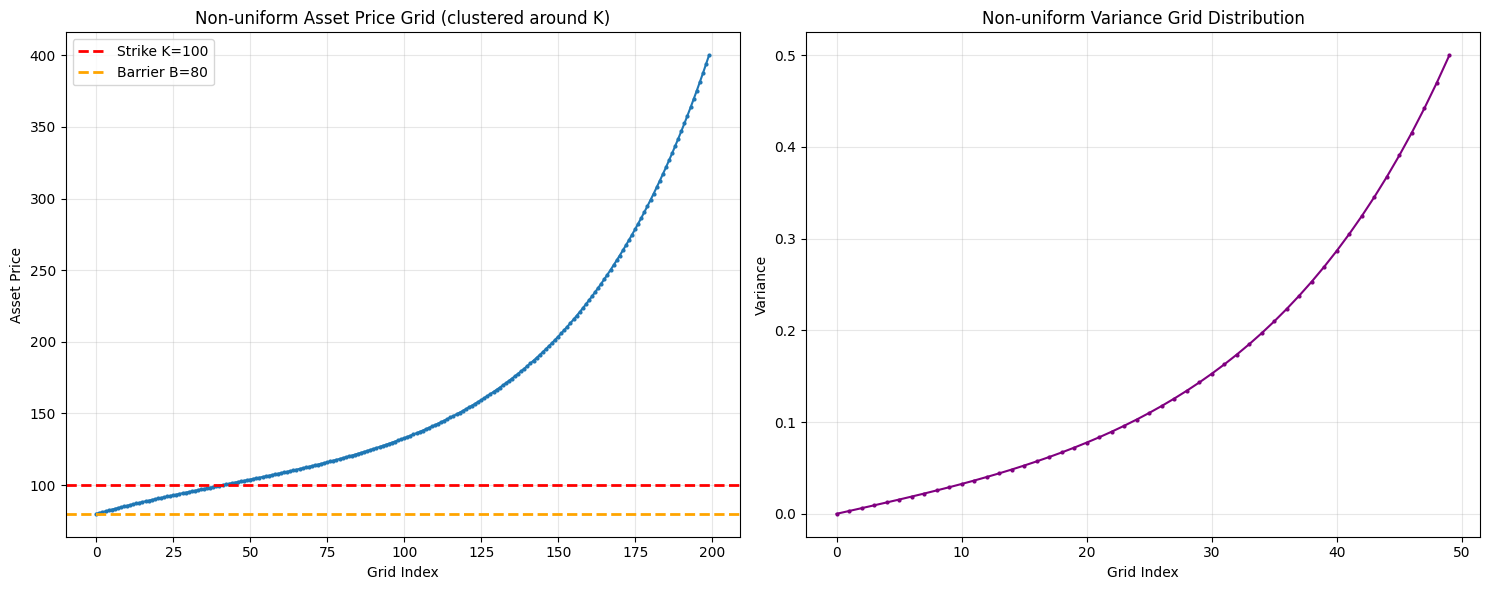

In [6]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Asset price grid
ax1.plot(range(len(S_grid)), S_grid, "o-", markersize=2)
ax1.axhline(K, color="r", linestyle="--", linewidth=2, label=f"Strike K={K}")
ax1.axhline(B, color="orange", linestyle="--", linewidth=2, label=f"Barrier B={B}")
ax1.set_xlabel("Grid Index")
ax1.set_ylabel("Asset Price")
ax1.set_title("Non-uniform Asset Price Grid (clustered around K)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Variance grid distribution
ax2.plot(range(len(v_grid)), v_grid, "o-", markersize=2, color="purple")
ax2.set_xlabel("Grid Index")
ax2.set_ylabel("Variance")
ax2.set_title("Non-uniform Variance Grid Distribution")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# State-value matrix: rows for S, columns for v
U = np.zeros((Ns, Nv))

# Terminal payoff for a call option: max(S-K, 0)
U[:, :] = np.maximum(S_grid[:, None] - K, 0.0)
U[S_grid <= B, :] = 0.0

In [8]:
def apply_boundary_conditions(U, S_grid, K, B, r, tau):
    """
    Apply boundary conditions for the barrier option.
    - For S <= B (below the barrier), the option value is 0.
    - For S = S_max, the option value approaches S-K.
    - For v = 0 (zero variance), the PDE degenerate.
    - For v = v_max (high variance), we can use a large value or extrapolation.
    """
    # Apply barrier condition
    U[S_grid <= B, :] = 0.0

    # Apply boundary condition for S_max
    U[-1, :] = S_max - K * np.exp(-r * tau)  # Discounted payoff at S_max

    # Apply high variance condition
    U[:, -1] = U[:, -2]  # Neumann condition (zero gradient) at v_max

    # Re-enforce barrier condition after applying other boundaries
    U[S_grid <= B, :] = 0.0

    return U

### 偏导


In [9]:
def first_derivative_matrix(x):
    """
    Create a first derivative matrix using central differences on a non-uniform grid.
    For interior points, use central differences.
    For boundaries, use forward/backward differences.
    """
    N = len(x)
    D = np.zeros((N, N))

    # Interior points: central differences
    for i in range(1, N - 1):
        # Central difference in the interior
        hm = x[i] - x[i - 1]  # Backward step
        hp = x[i + 1] - x[i]  # Forward step

        D[i, i - 1] = -hp / (hm * (hm + hp))
        D[i, i] = (hp - hm) / (hm * hp)
        D[i, i + 1] = hm / (hp * (hm + hp))

    # Forward difference at the left boundary
    D[0, 0] = -1 / (x[1] - x[0])
    D[0, 1] = 1 / (x[1] - x[0])

    # Backward difference at the right boundary
    D[N - 1, N - 2] = -1 / (x[N - 1] - x[N - 2])
    D[N - 1, N - 1] = 1 / (x[N - 1] - x[N - 2])

    return D


def second_derivative_matrix(x):
    """
    Second derivative matrix using central differences on a non-uniform grid.
    For interior points, use central differences.
    For boundaries, treat them later on PDE.
    """
    N = len(x)
    D2 = np.zeros((N, N))

    for i in range(1, N - 1):
        hm = x[i] - x[i - 1]  # Backward step
        hp = x[i + 1] - x[i]  # Forward step

        D2[i, i - 1] = 2 / (hm * (hm + hp))
        D2[i, i] = -2 / (hm * hp)
        D2[i, i + 1] = 2 / (hp * (hm + hp))

    return D2


D_S = first_derivative_matrix(S_grid)
D_SS = second_derivative_matrix(S_grid)
D_v = first_derivative_matrix(v_grid)
D_vv = second_derivative_matrix(v_grid)

U_S = D_S @ U
U_SS = D_SS @ U
U_v = U @ D_v.T
U_vv = U @ D_vv.T
U_Sv = D_S @ U @ D_v.T

print(D_S.shape, D_SS.shape, D_v.shape, D_vv.shape)
print(U_S.shape, U_SS.shape, U_v.shape, U_vv.shape, U_Sv.shape)

(200, 200) (200, 200) (50, 50) (50, 50)
(200, 50) (200, 50) (200, 50) (200, 50) (200, 50)


### 系数矩阵
$A = A0 + A1 + A2$
1. $A0 = \rho \sigma v S \frac{\partial^2 U}{\partial S \partial v}$，混合偏导部分
2. $A1 = \frac{1}{2}vS^2 \frac{\partial^2 U}{\partial S^2} + rS \frac{\partial U}{\partial S} - \frac{1}{2}rU$，S方向部分
3. $A2 = \frac{1}{2}\sigma^2 v \frac{\partial^2 U}{\partial v^2} + \kappa^*(\theta^* - v)\frac{\partial U}{\partial v} - \frac{1}{2}rU$，v方向部分

In [10]:
from scipy.sparse import diags, eye, kron, csr_matrix

I_S = eye(Ns, format="csr")
I_v = eye(Nv, format="csr")

S_diag = diags(S_grid, format="csr")
S2_diag = diags(S_grid**2, format="csr")
v_diag = diags(v_grid, format="csr")
kv_diag = diags(kappa * (theta - v_grid), format="csr")


def zero_sparse_rows(matrix, rows):
    if len(rows) == 0:
        return matrix
    row_mask = np.ones(matrix.shape[0], dtype=bool)
    row_mask[np.array(rows, dtype=int)] = False
    return matrix.multiply(row_mask[:, None]).tocsr()


boundary_rows = np.unique(
    np.concatenate(
        [
            np.arange(Ns),
            np.arange(0, Ns * Nv, Ns),
            np.arange(Ns - 1, Ns * Nv, Ns),
        ]
    )
)

# Mixed derivative part
A0 = rho * sigma * kron(v_diag @ D_v, S_diag @ D_S, format="csr")

# S-direction part
A1 = (
    0.5 * kron(v_diag, S2_diag @ D_SS, format="csr")
    + r * kron(I_v, S_diag @ D_S, format="csr")
    - 0.5 * r * eye(Ns * Nv, format="csr")
)

# v-direction part
A2 = (
    0.5 * sigma**2 * kron(v_diag @ D_vv, I_S, format="csr")
    + kron(kv_diag @ D_v, I_S, format="csr")
    - 0.5 * r * eye(Ns * Nv, format="csr")
)

A0 = zero_sparse_rows(A0, boundary_rows)
A1 = zero_sparse_rows(A1, boundary_rows)
A2 = zero_sparse_rows(A2, boundary_rows)

A = A0 + A1 + A2

In [11]:
adi_scheme = "MCS"  # "Douglas" or "MCS" (Modified Craig-Sneyd) are common choices. The MCS scheme is often preferred for its improved stability and accuracy, especially for problems with mixed derivatives like the Heston PDE.
theta_ADI = 1 / 3
use_rannacher = True

In [12]:
adi_scheme = "Douglas"  # "Douglas" or "MCS" (Modified Craig-Sneyd) are common choices. The MCS scheme is often preferred for its improved stability and accuracy, especially for problems with mixed derivatives like the Heston PDE.
theta_ADI = 0.5  # ADI scheme parameter. Common choices are 0.5 (Crank-Nicolson) or 1.0 (fully implicit). --- IGNORE ---
use_rannacher = True

In [13]:
import numpy as np
from scipy.sparse import eye, csr_matrix
from scipy.sparse.linalg import splu


def backward_euler_step(u_n, lu_be):
    return lu_be.solve(u_n)


def douglas_adi_step(u_n, dt, theta_adi, A, A1, A2, lu_M1, lu_M2):
    """
    One Douglas ADI step
    """
    Y0 = u_n + dt * (A @ u_n)

    rhs1 = Y0 - theta_adi * dt * (A1 @ u_n)
    Y1 = lu_M1.solve(rhs1)

    rhs2 = Y1 - theta_adi * dt * (A2 @ u_n)
    Y2 = lu_M2.solve(rhs2)

    return Y2


def mcs_adi_step(u_n, dt, theta_adi, A, A0, A1, A2, lu_M1, lu_M2):
    """
    One Modified Craig-Sneyd (MCS) ADI step
    """
    Y0 = u_n + dt * (A @ u_n)

    rhs1 = Y0 - theta_adi * dt * (A1 @ u_n)
    Y1 = lu_M1.solve(rhs1)

    rhs2 = Y1 - theta_adi * dt * (A2 @ u_n)
    Y2 = lu_M2.solve(rhs2)

    # Correction step for the mixed derivative term
    Y0_hat = Y0 + theta_adi * dt * (A0 @ (Y2 - u_n))
    Y0_tilde = Y0_hat + (0.5 - theta_adi) * dt * (A @ (Y2 - u_n))

    # Second implicit sweep
    rhs1_tilde = Y0_tilde - theta_adi * dt * (A1 @ u_n)
    Y1_tilde = lu_M1.solve(rhs1_tilde)

    rhs2_tilde = Y1_tilde - theta_adi * dt * (A2 @ u_n)
    Y2_tilde = lu_M2.solve(rhs2_tilde)

    return Y2_tilde


def apply_boundary_conditions(U_mat, S_grid, v_grid, K, B, r, tau):
    """
    Apply boundary conditions for the barrier option.
    - For S <= B (below the barrier), the option value is 0.
    - For S = S_max, the option value approaches S-K.
    - For v = 0 (zero variance), the PDE degenerate.
    - For v = v_max (high variance), we can use a large value or extrapolation.
    """
    S_max = S_grid[-1]
    # Apply barrier condition
    U_mat[S_grid <= B, :] = 0.0
    U_mat[0, :] = 0.0  # Boundary condition at S_min (or B if B > S_min)

    # Apply boundary condition for S_max
    U_mat[-1, :] = S_max - K * np.exp(-r * tau)  # Discounted payoff at S_max

    # Apply high variance condition
    U_mat[:, -1] = U_mat[:, -2]  # Neumann condition (zero gradient) at v_max

    # Re-enforce barrier condition after applying other boundaries
    U_mat[S_grid <= B, :] = 0.0

    return U_mat


def enforce_v0_boundary_condition(
    U_mat, S_grid, K, B, r, tau, dt_local, alpha_v0, lu_v0_local
):
    """
    Enforce the boundary condition at v=0, where the PDE degenerates.
    """
    U0_old = U_mat[:, 0].copy()
    U1 = U_mat[:, 1].copy()

    rhs = U0_old + dt_local * alpha_v0 * U1
    U0_new = lu_v0_local.solve(rhs)

    # Re-impose boundary conditions at v = 0
    U_mat[:, 0] = U0_new
    U_mat[S_grid <= B, 0] = 0.0
    U_mat[0, 0] = 0.0
    U_mat[-1, 0] = S_grid[-1] - K * np.exp(-r * tau)  # Boundary condition at S_max

    return U_mat


def solve_heston_adi(adi_scheme="MCS", theta_adi=1 / 3, use_rannacher=True):
    # Create the implicit matrices for the ADI steps
    dt = T / Nt
    theta_heston = theta

    u = U.flatten(order="F")
    I = eye(Ns * Nv, format="csr")

    # Directional implicit matrices for the ADI scheme
    M1 = (I - theta_adi * dt * A1).tocsc()
    M2 = (I - theta_adi * dt * A2).tocsc()
    lu_M1 = splu(M1)
    lu_M2 = splu(M2)

    # Optional Rannacher startup
    if use_rannacher and Nt >= 2:
        dt_rannacher = 0.5 * dt  # Use smaller time steps for the first few steps
        M_be = (I - dt_rannacher * A).tocsc()
        lu_be = splu(M_be)
    else:
        lu_be = None
        dt_rannacher = None

    # v= 0 reduced operator
    dv0 = v_grid[1] - v_grid[0]
    alpha_v0 = kappa * theta_heston / dv0

    I_S_sparse = eye(Ns, format="csr")
    D_S_sparse = csr_matrix(D_S)

    L_v0 = r * (S_diag @ D_S_sparse) - (alpha_v0 + r) * I_S_sparse
    L_v0 = zero_sparse_rows(
        L_v0.tocsr(), np.array([0, Ns - 1], dtype=int)
    ).tocsc()  # Enforce boundary conditions at S_min and S_max
    M_v0 = (I_S_sparse - dt * L_v0).tocsc()
    lu_v0 = splu(M_v0)

    if use_rannacher and dt_rannacher is not None:
        # Rannacher smoothing: take a few backward Euler steps at the start
        M_v0_rannacher = (I_S_sparse - dt_rannacher * L_v0).tocsc()
        lu_v0_rannacher = splu(M_v0_rannacher)
    else:
        lu_v0_rannacher = None

    U_work = U.copy()
    u = U_work.flatten(order="F")
    tau = T

    # Rannacher damping: two backward Euler steps with half time step
    if use_rannacher and dt_rannacher is not None and lu_be is not None:
        for k in range(2):
            tau -= dt_rannacher
            u = backward_euler_step(u, lu_be)
            U_work = u.reshape(Ns, Nv, order="F")
            U_work = apply_boundary_conditions(U_work, S_grid, v_grid, K, B, r, tau)
            U_work = enforce_v0_boundary_condition(
                U_work, S_grid, K, B, r, tau, dt_rannacher, alpha_v0, lu_v0_rannacher
            )
            u = U_work.flatten(order="F")

    # Main ADI time-stepping loop
    adi_start = 1 if use_rannacher and Nt >= 2 else 0

    for n in range(adi_start, Nt):
        tau -= dt

        if adi_scheme == "Douglas":
            u = douglas_adi_step(u, dt, theta_adi, A, A1, A2, lu_M1, lu_M2)
        elif adi_scheme == "MCS":
            u = mcs_adi_step(u, dt, theta_adi, A, A0, A1, A2, lu_M1, lu_M2)
        else:
            raise ValueError(f"Unknown ADI scheme: {adi_scheme}")

        U_work = u.reshape(Ns, Nv, order="F")
        U_work = apply_boundary_conditions(U_work, S_grid, v_grid, K, B, r, tau)
        U_work = enforce_v0_boundary_condition(
            U_work, S_grid, K, B, r, tau, dt, alpha_v0, lu_v0
        )
        u = U_work.flatten(order="F")

    i = np.argmin(np.abs(S_grid - S0))
    j = np.argmin(np.abs(v_grid - theta_heston))  # Start at the long-term variance
    price = U_work[i, j]

    return {"price": price, "theta_ADI": theta_adi}

adi_scheme = "MCS"  # "Douglas" or "MCS" (Modified Craig-Sneyd) are common choices. The MCS scheme is often preferred for its improved stability and accuracy, especially for problems with mixed derivatives like the Heston PDE.
theta_ADI = 1 / 3
use_rannacher = True
result = solve_heston_adi(adi_scheme=adi_scheme, theta_adi=theta_ADI, use_rannacher=use_rannacher)

print("ADI scheme:", adi_scheme)
print("theta_ADI:", theta_ADI)
print("option price at S0:", S0, "volatility:", np.sqrt(theta), "is:", result["price"])

adi_scheme = "Douglas"  # "Douglas" or "MCS" (Modified Craig-Sneyd) are common choices. The MCS scheme is often preferred for its improved stability and accuracy, especially for problems with mixed derivatives like the Heston PDE.
theta_ADI = 0.5  # ADI scheme parameter. Common choices are 0.5 (Crank-Nicolson) or 1.0 (fully implicit). --- IGNORE ---
use_rannacher = True
result = solve_heston_adi(adi_scheme=adi_scheme, theta_adi=theta_ADI, use_rannacher=use_rannacher)

print("ADI scheme:", adi_scheme)
print("theta_ADI:", theta_ADI)
print("option price at S0:", S0, "volatility:", np.sqrt(theta), "is:", result["price"])


ADI scheme: MCS
theta_ADI: 0.3333333333333333
option price at S0: 100 volatility: 0.2 is: 8.060524759268883
ADI scheme: Douglas
theta_ADI: 0.5
option price at S0: 100 volatility: 0.2 is: 8.060717590093802


## MCS Module Experiments

These experiments mirror the structure in `BarrierOption.ipynb`, but use the reusable module with `adi_scheme="MCS"` as the default.


In [14]:
import importlib
import barrier_heston_adi as bha

importlib.reload(bha)


<module 'barrier_heston_adi' from 'c:\\Users\\Jialu\\Codes\\barrier-option\\barrier_heston_adi.py'>

In [15]:
base_params = dict(
    S0=100,
    K=100,
    B=80,
    R=0,
    T=1,
    r=0.02,
    kappa=2.0,
    theta=0.04,
    sigma=0.5,
    rho=-0.7,
    S_min=0,
    S_max=400,
    v_min=0,
    v_max=0.5,
    Ns=200,
    Nv=50,
    Nt=100,
    c=20,
    d=0.05,
    theta_ADI=1.0 / 3.0,
    adi_scheme="MCS",
    use_rannacher=True,
    v0=0.04,
    debug=False,
)


[resolution_mcs] run 1/12 finished in 1.303s with price=8.074199157153
[resolution_mcs] run 2/12 finished in 1.842s with price=8.075820297623
[resolution_mcs] run 3/12 finished in 2.321s with price=8.077209956965
[resolution_mcs] run 4/12 finished in 3.208s with price=8.078168368883
[resolution_mcs] run 5/12 finished in 4.390s with price=8.079601115596
[resolution_mcs] run 6/12 finished in 6.109s with price=8.080455983232
[resolution_mcs] run 7/12 finished in 8.111s with price=8.081127659369
[resolution_mcs] run 8/12 finished in 11.200s with price=8.081485893351
[resolution_mcs] run 9/12 finished in 15.292s with price=8.081751599978
[resolution_mcs] run 10/12 finished in 22.964s with price=8.082024301281
[resolution_mcs] run 11/12 finished in 41.588s with price=8.083795652077
[resolution_mcs] run 12/12 finished in 124.814s with price=8.083906591131


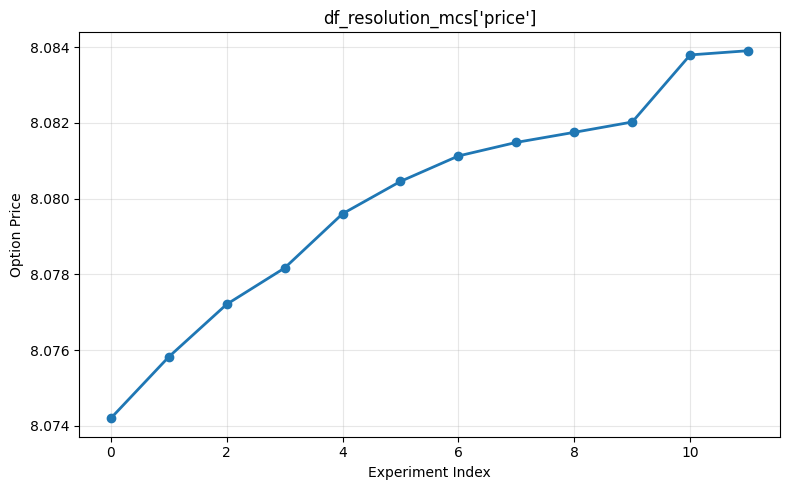

In [16]:
resolution_experiments = [
    {"Ns": 200, "Nv": 80, "Nt": 500},
    {"Ns": 220, "Nv": 90, "Nt": 600},
    {"Ns": 240, "Nv": 100, "Nt": 700},
    {"Ns": 260, "Nv": 110, "Nt": 800},
    {"Ns": 280, "Nv": 120, "Nt": 1000},
    {"Ns": 300, "Nv": 130, "Nt": 1200},
    {"Ns": 320, "Nv": 140, "Nt": 1400},
    {"Ns": 340, "Nv": 160, "Nt": 1600},
    {"Ns": 360, "Nv": 180, "Nt": 1800},
    {"Ns": 400, "Nv": 200, "Nt": 2000},
    {"Ns": 400, "Nv": 200, "Nt": 4000},
    {"Ns": 800, "Nv": 200, "Nt": 4000}
]

df_resolution_mcs = bha.run_experiment_grid(
    base_params, resolution_experiments, "resolution_mcs"
)

plt.figure(figsize=(8, 5))
plt.plot(df_resolution_mcs["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_resolution_mcs['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[domain_mcs] run 1/12 finished in 30.456s with price=8.081715609412
[domain_mcs] run 2/12 finished in 33.281s with price=8.082024301281
[domain_mcs] run 3/12 finished in 34.601s with price=8.082122431137
[domain_mcs] run 4/12 finished in 30.922s with price=8.082191388468
[domain_mcs] run 5/12 finished in 29.678s with price=8.081842799561
[domain_mcs] run 6/12 finished in 26.114s with price=8.082151489898
[domain_mcs] run 7/12 finished in 22.434s with price=8.082249616987
[domain_mcs] run 8/12 finished in 23.422s with price=8.082318572022
[domain_mcs] run 9/12 finished in 28.717s with price=8.081867323186
[domain_mcs] run 10/12 finished in 33.220s with price=8.082176011056
[domain_mcs] run 11/12 finished in 24.072s with price=8.082274137316
[domain_mcs] run 12/12 finished in 36.509s with price=8.082343091514


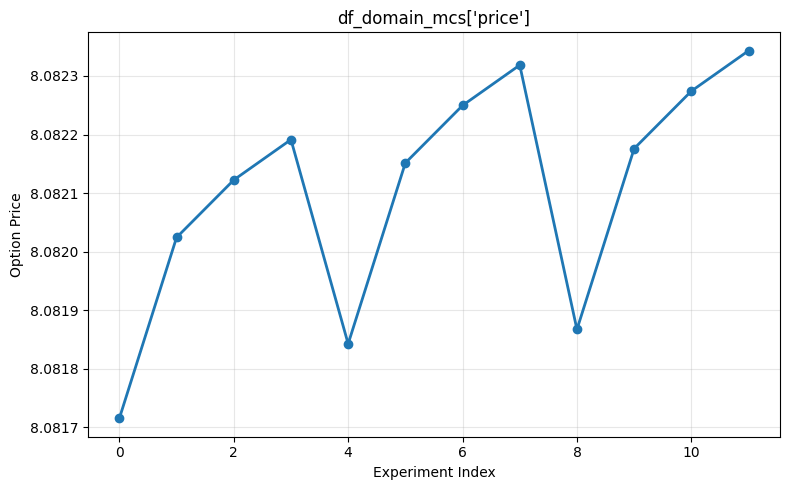

In [17]:
base_params.update(
    {
        "Ns": 400,
        "Nv": 200,
        "Nt": 2000,
    }
)

domain_experiments = [
    {"S_max": 400, "v_max": 0.3},
    {"S_max": 400, "v_max": 0.5},
    {"S_max": 400, "v_max": 0.7},
    {"S_max": 400, "v_max": 1.0},
    {"S_max": 600, "v_max": 0.3},
    {"S_max": 600, "v_max": 0.5},
    {"S_max": 600, "v_max": 0.7},
    {"S_max": 600, "v_max": 1.0},
    {"S_max": 800, "v_max": 0.3},
    {"S_max": 800, "v_max": 0.5},
    {"S_max": 800, "v_max": 0.7},
    {"S_max": 800, "v_max": 1.0},
]

df_domain_mcs = bha.run_experiment_grid(base_params, domain_experiments, "domain_mcs")

plt.figure(figsize=(8, 5))
plt.plot(df_domain_mcs["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_domain_mcs['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[theta_ADI_mcs] run 1/4 finished in 33.175s with price=8.082024301281
[theta_ADI_mcs] run 2/4 finished in 33.355s with price=8.082034891185
[theta_ADI_mcs] run 3/4 finished in 34.242s with price=8.082031388062
[theta_ADI_mcs] run 4/4 finished in 33.734s with price=8.082013794176


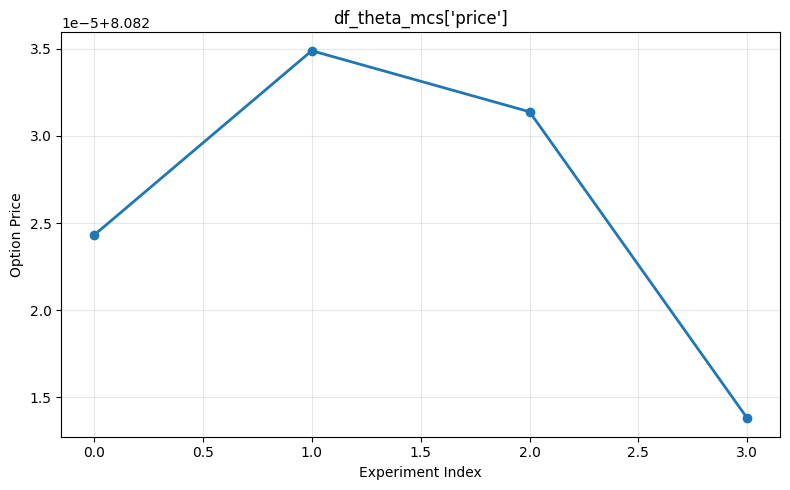

In [18]:
theta_experiments = [
    {"theta_ADI": 1.0 / 3.0},
    {"theta_ADI": 0.5},
    {"theta_ADI": 0.6},
    {"theta_ADI": 0.75},
]

df_theta_mcs = bha.run_experiment_grid(base_params, theta_experiments, "theta_ADI_mcs")

plt.figure(figsize=(8, 5))
plt.plot(df_theta_mcs["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_theta_mcs['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[asset_clustering_mcs] run 1/5 finished in 39.782s with price=8.082087478450
[asset_clustering_mcs] run 2/5 finished in 35.932s with price=8.082032599040
[asset_clustering_mcs] run 3/5 finished in 34.921s with price=8.082141536571
[asset_clustering_mcs] run 4/5 finished in 35.223s with price=8.082024301281
[asset_clustering_mcs] run 5/5 finished in 35.489s with price=8.082044281414


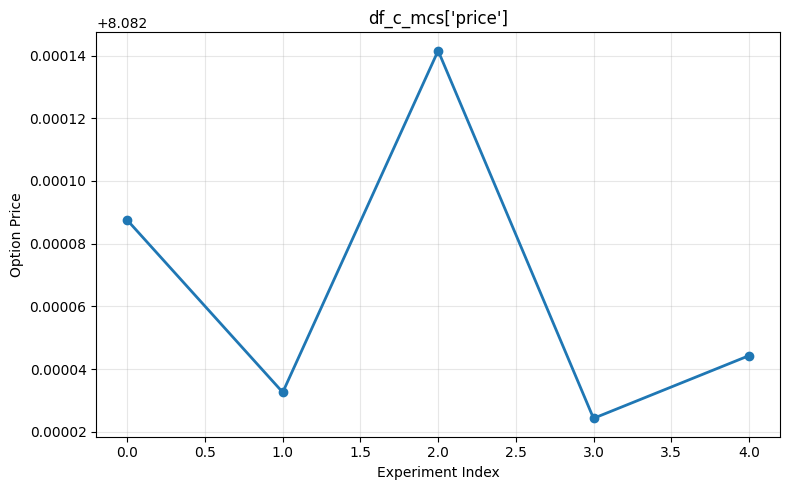

In [19]:
c_experiments = [
    {"c": 5},
    {"c": 10},
    {"c": 15},
    {"c": 20},
    {"c": 30},
]

df_c_mcs = bha.run_experiment_grid(base_params, c_experiments, "asset_clustering_mcs")

plt.figure(figsize=(8, 5))
plt.plot(df_c_mcs["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_c_mcs['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[variance_clustering_mcs] run 1/3 finished in 37.013s with price=8.081209178809
[variance_clustering_mcs] run 2/3 finished in 37.527s with price=8.082024301281
[variance_clustering_mcs] run 3/3 finished in 35.960s with price=8.082329386739


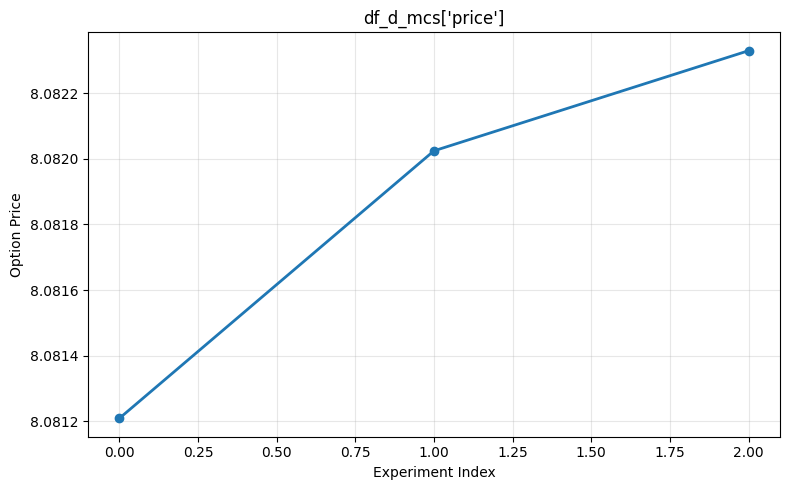

In [20]:
d_experiments = [
    {"d": 0.02},
    {"d": 0.05},
    {"d": 0.1},
]

df_d_mcs = bha.run_experiment_grid(base_params, d_experiments, "variance_clustering_mcs")

plt.figure(figsize=(8, 5))
plt.plot(df_d_mcs["price"], marker="o", linewidth=2)
plt.xlabel("Experiment Index")
plt.ylabel("Option Price")
plt.title("df_d_mcs['price']")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 希腊字母

此章节与`BarrierOption.ipynb`结构一致, 但使用模块：`adi_scheme="MCS"`.


In [21]:
import copy
import numpy as np
import importlib
import barrier_heston_adi as bha

importlib.reload(bha)


def price_from_params(params):
    if isinstance(params, dict):
        params = bha.KnockOutCallParams(**params)

    result = bha.price_european_down_and_out_call_heston_adi(params)
    return result["price"]


def compute_greeks(
    base_params,
    ds=1.0,
    dr=1e-4,
    dT=1 / 365,
    dv0=1e-4,
    dvol0=1e-3,
):
    p0 = copy.deepcopy(base_params)
    if p0["v0"] is None:
        p0["v0"] = p0["theta"]

    V0 = price_from_params(p0)

    p_up = copy.deepcopy(p0)
    p_dn = copy.deepcopy(p0)
    p_up["S0"] = p0["S0"] + ds
    p_dn["S0"] = max(1e-8, p0["S0"] - ds)

    V_up = price_from_params(p_up)
    V_dn = price_from_params(p_dn)

    delta = (V_up - V_dn) / (2 * ds)
    gamma = (V_up - 2 * V0 + V_dn) / (ds**2)

    p_r_up = copy.deepcopy(p0)
    p_r_dn = copy.deepcopy(p0)
    p_r_up["r"] = p0["r"] + dr
    p_r_dn["r"] = p0["r"] - dr

    V_r_up = price_from_params(p_r_up)
    V_r_dn = price_from_params(p_r_dn)

    rho = (V_r_up - V_r_dn) / (2 * dr)

    p_T_dn = copy.deepcopy(p0)
    p_T_dn["T"] = max(1e-8, p0["T"] - dT)
    V_T_dn = price_from_params(p_T_dn)
    theta_greek = -(V0 - V_T_dn) / dT

    p_v_up = copy.deepcopy(p0)
    p_v_dn = copy.deepcopy(p0)
    p_v_up["v0"] = p0["v0"] + dv0
    p_v_dn["v0"] = max(1e-8, p0["v0"] - dv0)

    V_v_up = price_from_params(p_v_up)
    V_v_dn = price_from_params(p_v_dn)

    vega_v0 = (V_v_up - V_v_dn) / (2 * dv0)

    vol0 = np.sqrt(p0["v0"])

    p_vol_up = copy.deepcopy(p0)
    p_vol_dn = copy.deepcopy(p0)

    vol_up = vol0 + dvol0
    vol_dn = max(1e-8, vol0 - dvol0)

    p_vol_up["v0"] = vol_up**2
    p_vol_dn["v0"] = vol_dn**2

    V_vol_up = price_from_params(p_vol_up)
    V_vol_dn = price_from_params(p_vol_dn)

    vega_vol0 = (V_vol_up - V_vol_dn) / (2 * dvol0)

    return {
        "price": V0,
        "delta": delta,
        "gamma": gamma,
        "rho": rho,
        "theta": theta_greek,
        "vega_v": vega_v0,
        "vega_vol": vega_vol0,
    }


greeks_mcs = compute_greeks(
    base_params,
    ds=1.0,
    dr=1e-4,
    dT=1 / 365,
    dv0=1e-4,
    dvol0=1e-3,
)

for k, v in greeks_mcs.items():
    print(f"{k}: {v:.8f}")


price: 8.08202430
delta: 0.67901251
gamma: 0.01996232
rho: 57.08563903
theta: -4.08534673
vega_v: 35.29637867
vega_vol: 14.11388504


从PDE表面直接获得:

`delta`, `gamma`, `vega_v`, and `theta_greek` 可以直接从PDE解析中获得。


In [22]:
import importlib
import barrier_heston_adi as bha

importlib.reload(bha)

params = bha.KnockOutCallParams(**base_params)
result = bha.price_european_down_and_out_call_heston_adi(params)

print(f"price: {result['price']:.10f}")
for k in ["delta", "gamma", "vega_v", "theta_greek"]:
    print(f"{k}: {result['greeks_pde'][k]:.10f}")


price: 8.0820243013
delta: 0.6792344592
gamma: 0.0198348762
vega_v: 35.2688634004
theta_greek: -4.0796321514
